In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

In [48]:
IMG_SIZE =224
BATCH_SIZE=32

In [49]:
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [57]:
train_path = "/kaggle/input/cataract-vs-normal-eye-dataset/Cataract/Train"

print(train_path)

/kaggle/input/cataract-vs-normal-eye-dataset/Cataract/Train


In [58]:
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='binary',
                                                    subset='training')

Found 6456 images belonging to 2 classes.


In [59]:
val_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='binary',
                                                    subset='validation')

Found 1612 images belonging to 2 classes.


In [94]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(512,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

In [95]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,207,233 (12.23 MB)

 Trainable params: 3,207,233 (12.23 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_generator,validation_data=val_generator,batch_size=BATCH_SIZE,epochs=10)

Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - accuracy: 0.6953 - loss: 0.5646 - val_accuracy: 0.8368 - val_loss: 0.4212
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8643 - loss: 0.3275 - val_accuracy: 0.9132 - val_loss: 0.2042
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.9295 - loss: 0.1849 - val_accuracy: 0.9454 - val_loss: 0.1426
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9480 - loss: 0.1323 - val_accuracy: 0.9479 - val_loss: 0.1371
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9703 - loss: 0.0824 - val_accuracy: 0.9646 - val_loss: 0.0864
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9748 - loss: 0.0689 - val_accuracy: 0.9677 - val_loss: 0.0885
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.9834 - loss: 0.0514 - val_accuracy: 0.9609 - val_loss: 0.1091
Epoch 8/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9850 - loss: 0

In [97]:
model.save('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/EyeCataractDetection.h5')

In [98]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [99]:
model=load_model('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/EyeCataractDetection.h5')
print("Model Loaded")

Model Loaded


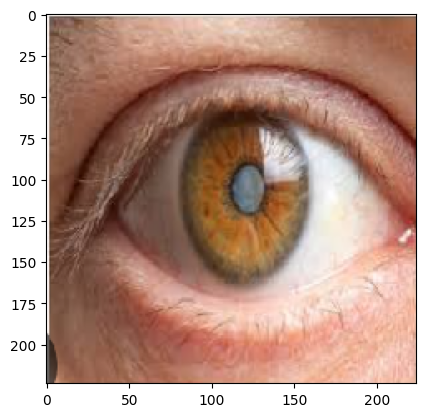

In [126]:
test_image_path="/content/Cataract03.png"
img=image.load_img(test_image_path,target_size=(224,224))
plt.imshow(img)
plt.axis()
plt.show()

In [127]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array /= 225.

prediction =  model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.9672464]]


In [128]:
if prediction >= 0.5:
  print("You have Cataract")
else:
  print("You don't have Cataract")

You have Cataract
